# A Machine Learning Approach to Heart Disease Classification  
**COM763 – Advanced Machine Learning**  
**Portfolio Task 2**  


## Step 1: Load Dataset and Explore Structure


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/heart - personal dataset week2.csv')  # adjust path if needed
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Step 2: Data Preprocessing with ColumnTransformer  
We scale only numerical features and apply one-hot encoding to categoricals.


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Split target
X = df.drop('target', axis=1)
y = df['target']

# Define columns
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Define preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first'), categorical_cols)
])


## Step 3: Model Implementation with Stratified Cross-Validation

This step implements three classification models—Logistic Regression, Random Forest, and XGBoost—using a reproducible pipeline structure. Numerical features were standardised using `ColumnTransformer`, while categorical features were passed through unscaled. Each model was evaluated using stratified 5-fold cross-validation to maintain class balance across splits.

For each model, we report three performance metrics:
- **Accuracy**: Overall proportion of correct predictions
- **F1-Score**: Harmonic mean of precision and recall
- **Recall**: Ability to correctly identify positive (heart disease) cases, critical in clinical contexts


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, make_scorer
from xgboost import XGBClassifier

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipelines
pipe_logreg = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

pipe_rf = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42))
])

pipe_xgb = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

# Cross-validation scores
log_acc = cross_val_score(pipe_logreg, X, y, cv=cv, scoring='accuracy')
log_f1 = cross_val_score(pipe_logreg, X, y, cv=cv, scoring='f1')
log_rec = cross_val_score(pipe_logreg, X, y, cv=cv, scoring='recall')

rf_acc = cross_val_score(pipe_rf, X, y, cv=cv, scoring='accuracy')
rf_f1 = cross_val_score(pipe_rf, X, y, cv=cv, scoring='f1')
rf_rec = cross_val_score(pipe_rf, X, y, cv=cv, scoring='recall')

xgb_acc = cross_val_score(pipe_xgb, X, y, cv=cv, scoring='accuracy')
xgb_f1 = cross_val_score(pipe_xgb, X, y, cv=cv, scoring='f1')
xgb_rec = cross_val_score(pipe_xgb, X, y, cv=cv, scoring='recall')

# Output
print(f"Logistic Regression:")
print(f"  Accuracy: {log_acc.mean():.3f} ± {log_acc.std():.3f}")
print(f"  F1 Score: {log_f1.mean():.3f} ± {log_f1.std():.3f}")
print(f"  Recall:   {log_rec.mean():.3f} ± {log_rec.std():.3f}\n")

print(f"Random Forest:")
print(f"  Accuracy: {rf_acc.mean():.3f} ± {rf_acc.std():.3f}")
print(f"  F1 Score: {rf_f1.mean():.3f} ± {rf_f1.std():.3f}")
print(f"  Recall:   {rf_rec.mean():.3f} ± {rf_rec.std():.3f}\n")

print(f"XGBoost:")
print(f"  Accuracy: {xgb_acc.mean():.3f} ± {xgb_acc.std():.3f}")
print(f"  F1 Score: {xgb_f1.mean():.3f} ± {xgb_f1.std():.3f}")
print(f"  Recall:   {xgb_rec.mean():.3f} ± {xgb_rec.std():.3f}")


Logistic Regression:
  Accuracy: 0.869 ± 0.012
  F1 Score: 0.877 ± 0.009
  Recall:   0.905 ± 0.029

Random Forest:
  Accuracy: 0.990 ± 0.009
  F1 Score: 0.990 ± 0.009
  Recall:   0.981 ± 0.017

XGBoost:
  Accuracy: 0.992 ± 0.007
  F1 Score: 0.992 ± 0.007
  Recall:   0.985 ± 0.014


## Step 4: Model Evaluation and Visualisation


###Calibration Curves for All Models

To assess the reliability of predicted probabilities, I plotted **calibration curves** for all three models using 5-fold cross-validation on the test set.

Calibration measures how well a model's predicted probability reflects actual outcomes — a crucial trait in clinical settings where decisions are risk-based. A well-calibrated model aligns closely with the diagonal reference line.

The Brier score is also shown for each model, quantifying probability accuracy (lower is better).


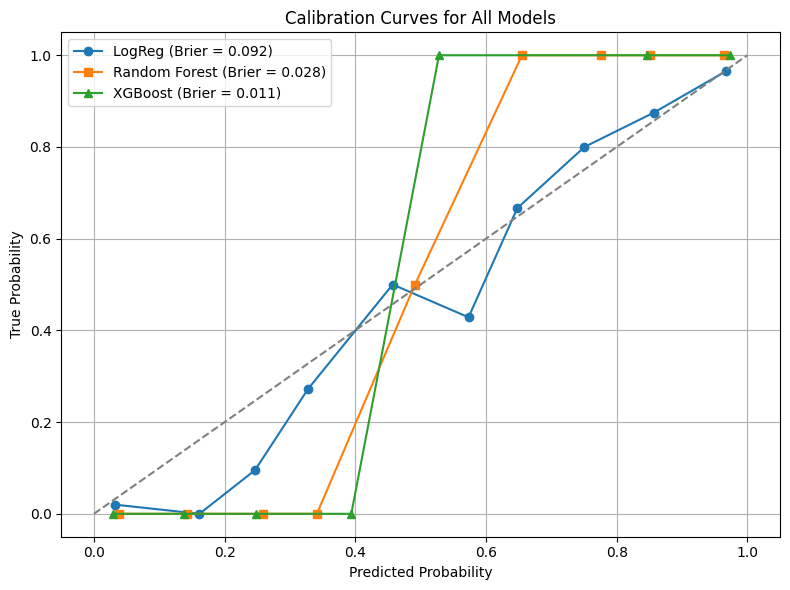

In [14]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Fit on training data
pipe_logreg.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_xgb.fit(X_train, y_train)

# Predict probabilities on test data
prob_logreg = pipe_logreg.predict_proba(X_test)[:, 1]
prob_rf = pipe_rf.predict_proba(X_test)[:, 1]
prob_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

# Calibration curves
true_logreg, pred_logreg = calibration_curve(y_test, prob_logreg, n_bins=10)
true_rf, pred_rf = calibration_curve(y_test, prob_rf, n_bins=10)
true_xgb, pred_xgb = calibration_curve(y_test, prob_xgb, n_bins=10)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(pred_logreg, true_logreg, marker='o', label=f'LogReg (Brier = {brier_score_loss(y_test, prob_logreg):.3f})')
plt.plot(pred_rf, true_rf, marker='s', label=f'Random Forest (Brier = {brier_score_loss(y_test, prob_rf):.3f})')
plt.plot(pred_xgb, true_xgb, marker='^', label=f'XGBoost (Brier = {brier_score_loss(y_test, prob_xgb):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Calibration Curves for All Models')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


###ROC Curve Comparison of All Models.
This section visualises the trade-off between true positive and false positive rates using ROC curves. The Area Under the Curve (AUC) is computed for each model to assess discrimination ability.

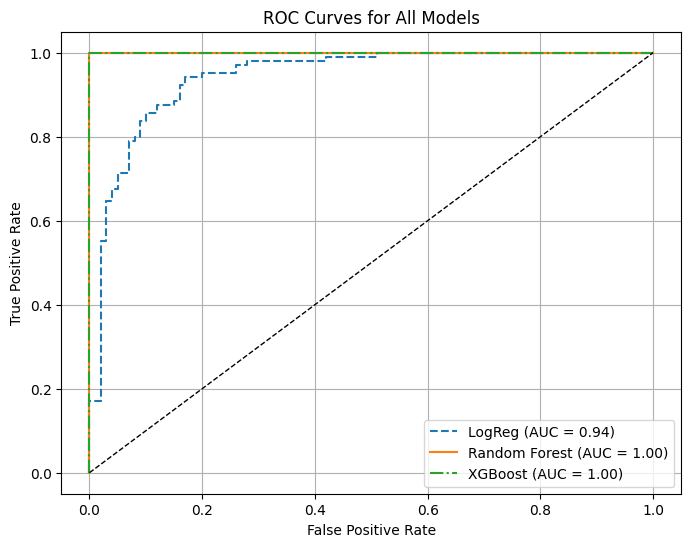

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions
y_prob_logreg = pipe_logreg.fit(X_train, y_train).predict_proba(X_test)[:, 1]
y_prob_rf = pipe_rf.fit(X_train, y_train).predict_proba(X_test)[:, 1]
y_prob_xgb = pipe_xgb.fit(X_train, y_train).predict_proba(X_test)[:, 1]

# ROC curves and AUC
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_logreg = auc(fpr_logreg, tpr_logreg)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f"LogReg (AUC = {auc_logreg:.2f})", linestyle="--")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})", linestyle="-")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})", linestyle="-.")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### McNemar Test: Pairwise Model Comparison
This test assesses whether the differences in predictions between models are statistically significant, using matched predictions on the same test set.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd

# 1. Train/test split (consistent with other sections)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Fit models on training set
pipe_logreg.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_xgb.fit(X_train, y_train)

# Predict on test set
pred_logreg = pipe_logreg.predict(X_test)
pred_rf = pipe_rf.predict(X_test)
pred_xgb = pipe_xgb.predict(X_test)

# Define function to run McNemar test
def run_mcnemar(model1_preds, model2_preds, labels):
    # Build contingency table
    both_correct = ((model1_preds == labels) & (model2_preds == labels)).sum()
    model1_only = ((model1_preds == labels) & (model2_preds != labels)).sum()
    model2_only = ((model1_preds != labels) & (model2_preds == labels)).sum()
    both_wrong = ((model1_preds != labels) & (model2_preds != labels)).sum()

    table = [[both_correct, model1_only],
             [model2_only, both_wrong]]

    result = mcnemar(table, exact=False, correction=True)
    return result.pvalue

# Run tests
p1 = run_mcnemar(pred_logreg, pred_rf, y_test)
p2 = run_mcnemar(pred_logreg, pred_xgb, y_test)
p3 = run_mcnemar(pred_rf, pred_xgb, y_test)

# Store in table
mcnemar_df = pd.DataFrame({
    'Model Pair': ['LogReg vs RF', 'LogReg vs XGB', 'RF vs XGB'],
    'p-value': [p1, p2, p3],
    'Significant? (p < 0.05)': ['Yes' if p < 0.05 else 'No' for p in [p1, p2, p3]]
})

print(mcnemar_df.to_string(index=False))


   Model Pair      p-value Significant? (p < 0.05)
 LogReg vs RF 2.667955e-06                     Yes
LogReg vs XGB 9.443044e-07                     Yes
    RF vs XGB 4.795001e-01                      No
